<a href="https://colab.research.google.com/github/pachterlab/cellmender/blob/main/benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellsweep import denoise_count_matrix
# except ImportError:
#     print("cellsweep not found, installing...")
#     !pip install -U -q cellsweep[analysis]

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import itertools
import yaml
import requests
import matplotlib.pyplot as plt
import anndata as ad
from collections import OrderedDict
import seaborn as sns
import scanpy as sc
from cellsweep import denoise_count_matrix
import cellsweep.utils as cs_utils

cellsweep_dir = os.path.dirname(os.path.abspath(""))
rver_docker_workspace = "/home/ruser/work/cellsweep"

# Compare CellBender vs. cellsweep

Some datasets of use:
- pbmc8k: 8k PBMCs from a healthy donor (CellBender Fig2): https://www.10xgenomics.com/datasets/8-k-pbm-cs-from-a-healthy-donor-2-standard-2-1-0
  - see run configuration on page 13 (bottom left) of the [Cellbender manuscript](https://doi.org/10.1038/s41592-023-01943-7)
- hgmm12k: Human-mouse mixture (CellBender Fig5): https://support.10xgenomics.com/single-cell-gene-expression/datasets/2.1.0/hgmm_12k

In [3]:
dataset_name = "8cubed"
alternative_tools = []  # ["cellbender", "soupx", "decontx", "scar"]
debug = True
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False  # overwrite existing files
scar_env = "/home/jrich/miniconda3/envs/scar"
use_cuda = False  # for CellBender and scAR
threads = 8  # for cellsweep and CellBender (if use_cuda=False)

In [4]:
# load yaml
yaml_file = os.path.join(cellsweep_dir, "notebooks", "config", f"{dataset_name}.yaml")
cfg = cs_utils.load_dataset_yaml(yaml_file)

# create directories for data, output
data_dir = os.path.join(cellsweep_dir, "notebooks", "data", dataset_name)
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellsweep_dir, "notebooks", "output", dataset_name)
os.makedirs(out_dir, exist_ok=True)

# set file paths for tools
out_dir_cellsweep = os.path.join(data_dir, "cellsweep")
out_dir_cellbender = os.path.join(data_dir, "cellbender")
out_dir_soupx = os.path.join(data_dir, "soupx")
out_dir_decontx = os.path.join(data_dir, "decontx")
out_dir_scar = os.path.join(data_dir, "scar")

# lay out parameters
model_pkl = cfg["model_pkl"]
celltypist_convert = cfg["celltypist_convert"]
celltypist_map_file = cfg["celltypist_map_file"]
cellsweep_max_iter = cfg["cellsweep_max_iter"]
cellsweep_beta = cfg["cellsweep_beta"]
cellsweep_init_alpha = cfg["cellsweep_init_alpha"]
cellbender_epochs = cfg["cellbender_epochs"]
cellbender_fpr = cfg["cellbender_fpr"]
cellbender_zdim = cfg["cellbender_zdim"]
cellbender_expected_cells = cfg["cellbender_expected_cells"]
cellbender_total_droplets = cfg["cellbender_total_droplets"]
scar_epochs = cfg["scar_epochs"]
scar_prob = cfg["scar_prob"]
expected_cells = cfg["expected_cells"]
min_genes = cfg["min_genes"]
min_cells = cfg["min_cells"]
umi_top_percentile_to_remove = cfg["umi_top_percentile_to_remove"]
fraction_doublet = cfg["fraction_doublet"]
unique_genes_top_percentile_to_remove = cfg["unique_genes_top_percentile_to_remove"]
mt_gene_percentile_to_remove = cfg["mt_gene_percentile_to_remove"]
max_mt_percentage = cfg["max_mt_percentage"]
n_top_genes = cfg["n_top_genes"]
n_pcs = cfg["n_pcs"]
n_neighbors = cfg["n_neighbors"]
leiden_resolution = cfg["leiden_resolution"]
marker_genes = cfg["marker_genes"]

backed = "r" if debug else None

## Raw

In [5]:
adata_tmp = ad.read_h5ad("/mnt/data1/igvf_003/CortexHippocampus/adata.h5ad", backed="r")
adata_tmp

AnnData object with n_obs × n_vars = 1379074 × 56953 backed at '/mnt/data1/igvf_003/CortexHippocampus/adata.h5ad'
    obs: 'bc', 'bc1_sequence', 'bc2_sequence', 'bc3_sequence', 'subpool', 'bc1_well', 'bc2_well', 'bc3_well', 'Mouse_Tissue_ID', 'alias_tissue1', 'alias_tissue2', 'alias_tissue3', 'alias_tissue4', 'plate', 'Protocol', 'Chemistry', 'well_type', 'Row', 'Column', 'Genotype', 'Notes', 'Multiplexed_sample1', 'Multiplexed_sample2', 'SampleType', 'Tissue', 'Tissue_ID', 'Tissue1_ontology_id', 'Tissue2_ontology_id', 'Sex', 'Replicate', 'DOB', 'Age_weeks', 'Age_days', 'Body_weight_g', 'Estrus_cycle', 'Dissection_date', 'Dissection_time', 'Dissector', 'Tissue_weight_mg', 'mult_genotype_1', 'mult_genotype_2', 'mult_genotype', 'n_counts', 'B6J', 'NODJ', '129S1J', 'CASTJ', 'AJ', 'PWKJ', 'WSBJ', 'NZOJ', 'doublet_scores', 'batch'
    var: 'gene_name'

In [ ]:
def load_8cubed_raw_data(adata_dir):
    # plate: adata
    plates = ["igvf_003", "igvf_004", "igvf_005", "igvf_007", "igvf_008b", "igvf_009", "igvf_010", "igvf_011", "igvf_012"]
    adata_dict = {}
    for plate in plates:
        adatas_plate = []
        plate_dir = os.path.join(adata_dir, plate)
        for tissue in os.listdir(plate_dir):
            adata_path = os.path.join(plate_dir, tissue, "filtered_feature_bc_matrix.h5ad")
            adata = ad.read_h5ad(adata_path)
            adatas_plate.append(adata)
        adata_plate = ad.concat(adatas_plate, axis=0, join="outer", label="Tissue", keys=[tissue for tissue in os.listdir(plate_dir)])
        adata_dict[plate] = adata_plate
    return adata_dict

def load_8cubed_filtered_data(adata_dir, backed=None):
    # tissue: adata
    try:
        from tqdm import tqdm
        tq = tqdm
    except ImportError:
        # no tqdm → identity function
        tq = lambda x, *args, **kwargs: x

    # List .h5ad files
    files = sorted([os.path.join(adata_dir, f) for f in os.listdir(adata_dir) if f.endswith(".h5ad")])

    if not files:
        raise ValueError(f"No .h5ad files found in: {adata_dir}")

    print(f"Found {len(files)} files:")
    for f in files:
        print("  -", f)

    # Load them
    adata_dict = {}
    for filename in tq(files, desc="Loading AnnData files"):
        tissue = os.path.basename(filename).replace(".h5ad", "")
        adata = ad.read_h5ad(filename, backed=backed)
        adata_dict[tissue] = adata

    return adata_dict

def merge_filtered_celltype_into_raw(adata_raw_plate_dict, adata_filtered_tissue_dict):
    adata_raw_plate_with_celltype_dict = {}
    for adata in adata_raw_plate_dict.values():
        # For each tissue present in this plate
        for tissue in adata.obs["Tissue"].unique():

            if tissue not in adata_filtered_tissue_dict:
                print(f"[WARN] Tissue {tissue} not found in adata_filtered_tissue_dict — skipping")
                continue

            adata_filtered = adata_filtered_tissue_dict[tissue]

            # Extract only the filtered cells for this tissue from the filtered dataset
            filt_obs = adata_filtered.obs[["celltype"]].copy()

            # Restrict to matching cell indices (intersection)
            common_idx = adata.obs.index.intersection(filt_obs.index)
            filt_obs = filt_obs.loc[common_idx]

            # Add a temporary column for merge
            colname = f"{tissue}_celltype"

            # Initialize with "Empty Droplet"
            adata.obs[colname] = "Empty Droplet"

            # Fill real celltype annotations where available
            adata.obs.loc[common_idx, colname] = filt_obs["celltype"]
        
        adata_raw_plate_with_celltype_dict[adata.uns["plate_id"]] = adata        
    
    return adata_raw_plate_with_celltype_dict

In [ ]:
adata_raw_plate_dict = load_8cubed_raw_data(cfg["adata_raw_parent_dir"])
adata_filtered_tissue_dict = load_8cubed_filtered_data(cfg["adata_filtered_dir"], backed=backed)

In [ ]:
adata_raw_plate_dict = merge_filtered_celltype_into_raw(adata_raw_plate_dict, adata_filtered_tissue_dict)

In [ ]:
adata_raw_dict = cs_utils.load_adata(cfg["adata_dir"], multiple_anndatas=True, backed=backed, verbose=verbose)
adata_raw_dict = {}
for adata_raw in adata_raw_list:
    if debug:
        adata_raw = adata_raw[list(adata_raw.obs.index[:1000]), :].to_memory()
    adata_raw.var_names_make_unique()
    tissue = adata_raw.obs["Tissue"].unique()[0]
    adata_raw_dict[tissue] = adata_raw
eight_cubed_markers_path = os.path.join(data_dir, "8_cube_marker_genes.csv")

# print(cs_utils.matrices_equal(adata_raw_dict["Adrenal"].X, adata_raw_dict["Adrenal"].layers["raw_counts"]))  # to confirm non-equality

Found 9 files:
  - /mnt/data1/8_cube/Adrenal_annotated.h5ad
  - /mnt/data1/8_cube/CortexHippocampus_annotated.h5ad
  - /mnt/data1/8_cube/Gastrocnemius_annotated.h5ad
  - /mnt/data1/8_cube/GonadsFemale_annotated.h5ad
  - /mnt/data1/8_cube/GonadsMale_annotated.h5ad
  - /mnt/data1/8_cube/Heart_annotated.h5ad
  - /mnt/data1/8_cube/HypothalamusPituitary_annotated.h5ad
  - /mnt/data1/8_cube/Kidney_annotated.h5ad
  - /mnt/data1/8_cube/Liver_annotated.h5ad












Loading AnnData files: 100%|██████████| 9/9 [01:06<00:00,  7.39s/it]


## Knee plot - use this output to estimate umi_cutoff

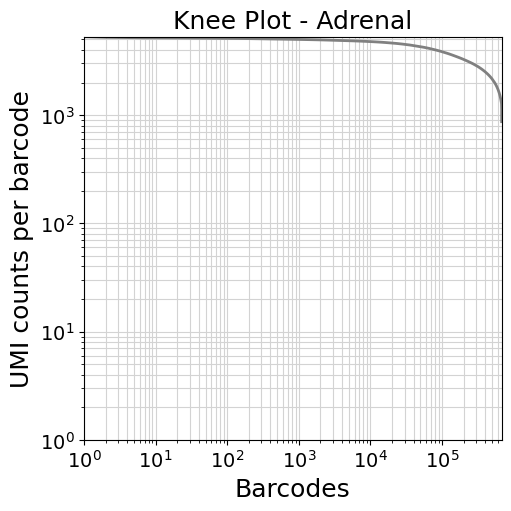

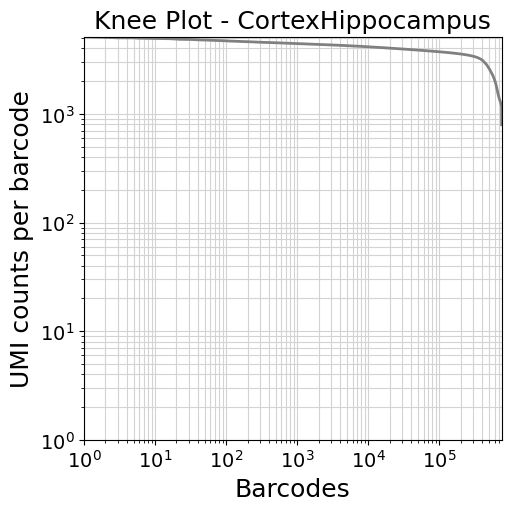

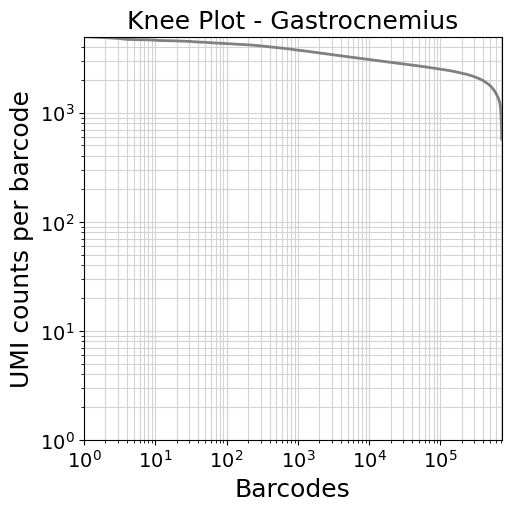

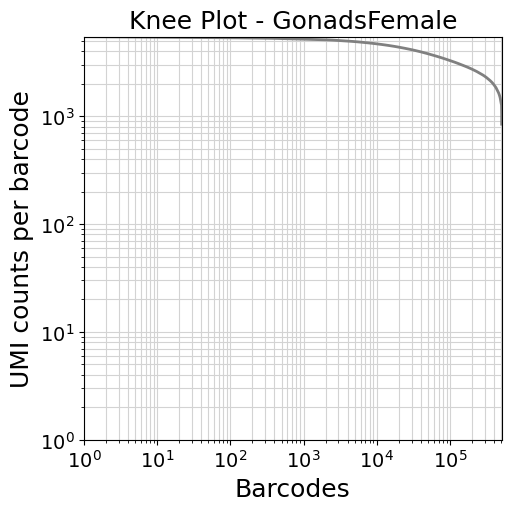

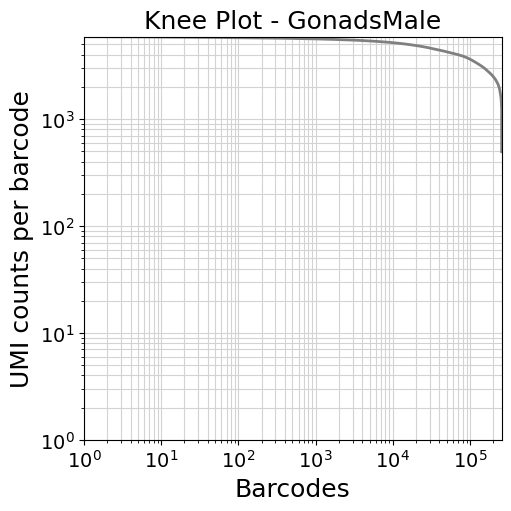

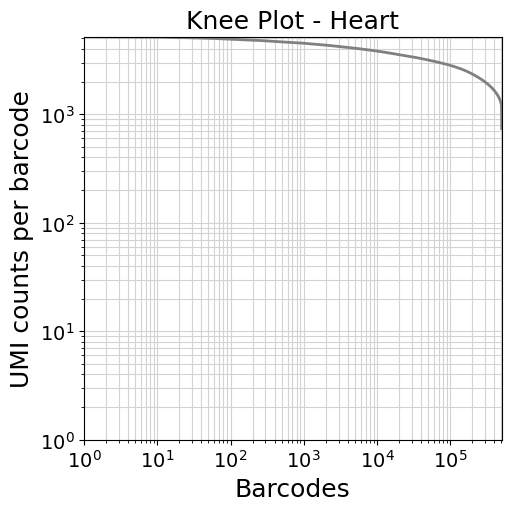

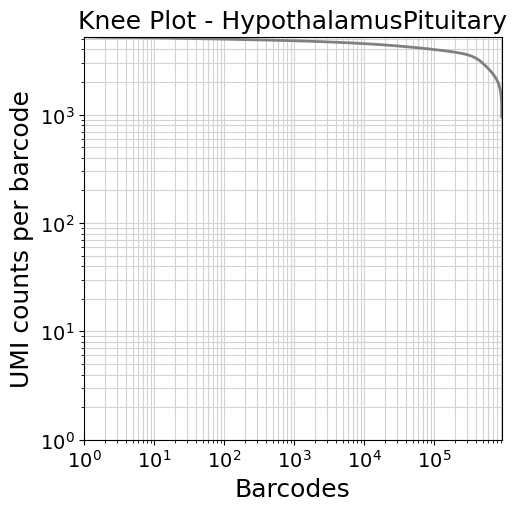

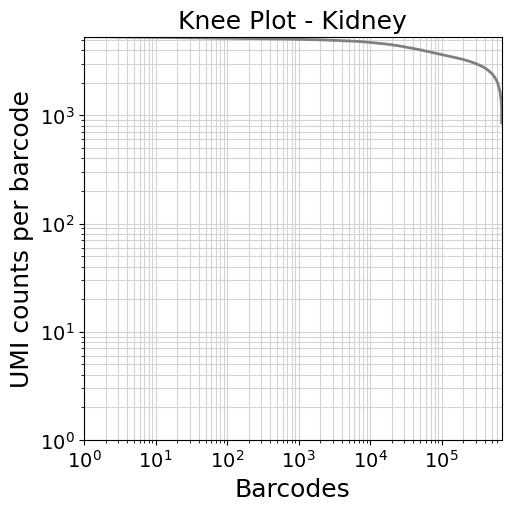

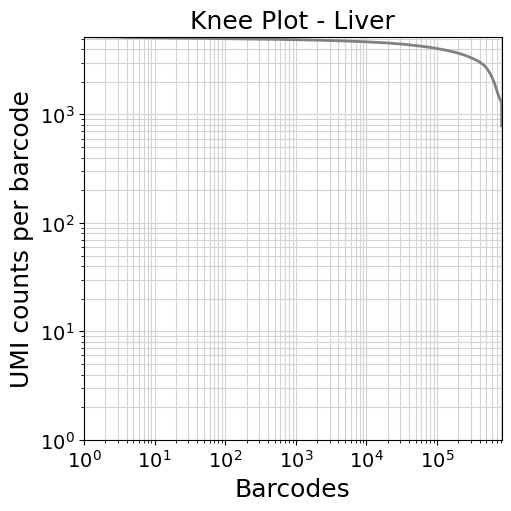

In [ ]:
if not debug:
    umi_cutoffs = {}
    for tissue, adata_raw in adata_raw_dict.items():
        umi_cutoff = cs_utils.knee_plot(adata_raw, expected_cells=expected_cells, title=f"Knee Plot - {tissue}", out_path=os.path.join(out_dir, f"knee_plot_{tissue}.png"))
        umi_cutoffs[tissue] = umi_cutoff

In [ ]:
#!!! optionally update umi_cutoffs from knee plot - required for None values
umi_cutoffs

{'Adrenal': None,
 'CortexHippocampus': None,
 'Gastrocnemius': None,
 'GonadsFemale': None,
 'GonadsMale': None,
 'Heart': None,
 'HypothalamusPituitary': None,
 'Kidney': None,
 'Liver': None}

In [ ]:
if not debug:
    adata_raw_filtered_dict = {}
    for tissue, adata_raw in adata_raw_dict.items():
        adata_raw = cs_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoffs[tissue], verbose=verbose)  # adds adata.obs["is_empty"]
        adata_raw.var['empty_counts'] = np.array(adata_raw.X[adata_raw.obs['is_empty'].values, :].sum(axis=0)).flatten()
        adata_raw_dict[tissue] = adata_raw
        adata_raw_filtered = adata_raw[~adata_raw.obs["is_empty"]].copy()
        adata_raw_filtered_dict[tissue] = adata_raw_filtered

## cellsweep

In [ ]:
if not debug:
    adata_cellsweep_dict = {}
    for tissue, adata_raw in adata_raw_dict.items():
        print(f"Processing Cellsweep for {tissue}...")
        adata_path_cellsweep = os.path.join(out_dir_cellsweep, f"{tissue}_cellsweep.h5ad")
        if not os.path.exists(adata_path_cellsweep) or overwrite:
            adata_cellsweep = denoise_count_matrix(adata_raw, adata_out=adata_path_cellsweep, beta=cellsweep_beta, freeze_ambient_profile=True, init_alpha=cellsweep_init_alpha, max_iter=cellsweep_max_iter, empty_droplet_method="threshold", expected_cells=expected_cells, threads=threads, verbose=verbose, log_file=os.path.join(data_dir, "cellsweep.log"))
        else:
            adata_cellsweep = ad.read_h5ad(adata_path_cellsweep)
        adata_cellsweep = adata_cellsweep[~adata_cellsweep.obs["is_empty"]].copy()
        adata_cellsweep.var_names_make_unique()
        adata_cellsweep_dict[tissue] = adata_cellsweep

# Analysis

In [19]:
if debug:
    adata_raw_filtered_dict = adata_raw_dict.copy()
    adata_cellsweep_dict = adata_raw_dict.copy()

In [20]:
for tissue in adata_raw_dict.keys():
    print(f"Tissue: {tissue}")
    print(f"Adata raw (filtered cells): {adata_raw_filtered_dict[tissue]}")
    print(f"Adata cellsweep: {adata_cellsweep_dict[tissue]}\n\n")

Tissue: Adrenal
Adata raw (filtered cells): AnnData object with n_obs × n_vars = 1000 × 56953
    obs: 'bc', 'bc1_sequence', 'bc2_sequence', 'bc3_sequence', 'subpool', 'bc1_well', 'bc2_well', 'bc3_well', 'Mouse_Tissue_ID', 'alias_tissue1', 'alias_tissue2', 'alias_tissue3', 'alias_tissue4', 'plate', 'Protocol', 'Chemistry', 'well_type', 'Row', 'Column', 'Genotype', 'Notes', 'Multiplexed_sample1', 'Multiplexed_sample2', 'SampleType', 'Tissue', 'Tissue_ID', 'Tissue1_ontology_id', 'Tissue2_ontology_id', 'Sex', 'Replicate', 'DOB', 'Age_weeks', 'Age_days', 'Body_weight_g', 'Estrus_cycle', 'Dissection_date', 'Dissection_time', 'Dissector', 'Tissue_weight_mg', 'mult_genotype_1', 'mult_genotype_2', 'mult_genotype', 'n_counts', 'doublet_scores', 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predictions', 'leiden_R', 'general_celltype', 'general_CL_ID', 'celltype', 'CL_ID', 'subtype'
    var: 'gene_name', 'mt', 'n_cells_by_counts', 'mean_c

In [29]:
def concatenate_adatas(adata_list):
    adatas = []
    for adata in adata_list:
        adatas.append(adata)
    adata_combined = ad.concat(adatas, join="outer", label="Tissue", keys=list(adata_raw_filtered_dict.keys()))
    return adata_combined

adata_raw_filtered = concatenate_adatas(adata_raw_filtered_dict.values())
adata_cellsweep = concatenate_adatas(adata_cellsweep_dict.values())

adata_dict = {
    "raw": adata_raw_filtered,
    "cellsweep": adata_cellsweep
}
adata_dict

/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/anndata/_core/merge.py:1434: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(
Loading AnnData files:   0%|          | 0/9 [10:03<?, ?it/s]
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/anndata/_core/merge.py:1434: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(


{'raw': AnnData object with n_obs × n_vars = 9000 × 113613
     obs: 'bc', 'bc1_sequence', 'bc2_sequence', 'bc3_sequence', 'subpool', 'bc1_well', 'bc2_well', 'bc3_well', 'Mouse_Tissue_ID', 'alias_tissue1', 'alias_tissue2', 'alias_tissue3', 'alias_tissue4', 'plate', 'Protocol', 'Chemistry', 'well_type', 'Row', 'Column', 'Genotype', 'Notes', 'Multiplexed_sample1', 'Multiplexed_sample2', 'SampleType', 'Tissue', 'Tissue_ID', 'Tissue1_ontology_id', 'Tissue2_ontology_id', 'Sex', 'Replicate', 'DOB', 'Age_weeks', 'Age_days', 'Body_weight_g', 'Estrus_cycle', 'Dissection_date', 'Dissection_time', 'Dissector', 'Tissue_weight_mg', 'mult_genotype_1', 'mult_genotype_2', 'mult_genotype', 'n_counts', 'doublet_scores', 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predictions', 'leiden_R', 'general_celltype', 'general_CL_ID', 'celltype', 'CL_ID', 'subtype', 'cellID', 'WSBJ', 'NZOJ', '129S1J', 'CASTJ', 'B6J', 'NODJ', 'AJ', 'PWKJ', 'ryan_annotatio

## Save Anndatas

In [ ]:
for tool, adata in adata_dict.items():
    adata_path = os.path.join(data_dir, tool, f"combined_{tool}.h5ad")
    os.makedirs(os.path.dirname(adata_path), exist_ok=True)
    adata.write_h5ad(adata_path)

## 8 Cubed Analysis

Skipping Heart vs Liver joint scatterplot due to no common plate.
Skipping Liver vs HypothalamusPituitary joint scatterplot due to no common plate.
Skipping HypothalamusPituitary vs Gonads joint scatterplot due to no common plate.
Skipping Gonads vs Adrenal joint scatterplot due to no common plate.
Skipping Adrenal vs Kidney joint scatterplot due to no common plate.
Skipping Kidney vs Gastrocnemius joint scatterplot due to no common plate.
Skipping Gastrocnemius vs CortexHippocampus joint scatterplot due to no common plate.


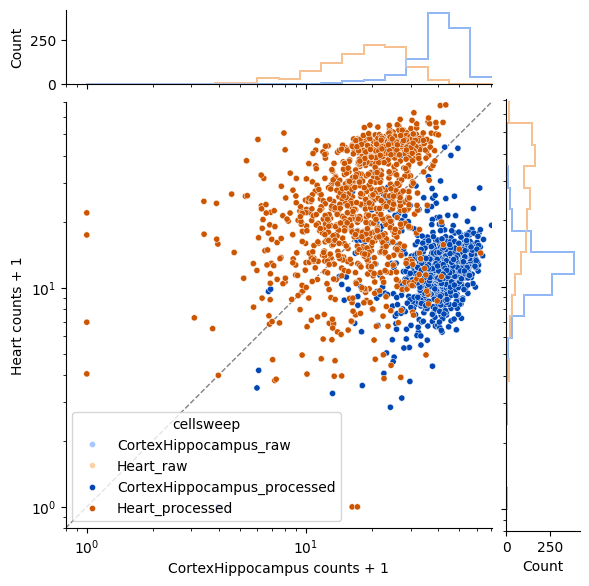

In [42]:
# import os
# import anndata as ad
# import cellsweep.utils as cs_utils
# cellsweep_dir = os.path.dirname(os.path.abspath(""))
# data_dir = os.path.join(cellsweep_dir, "notebooks", "data", "8cubed")
# adata_dict = {}
# for tool in ["raw", "cellsweep"]:
#     adata_path = os.path.join(data_dir, tool, f"combined_{tool}.h5ad")
#     adata_dict[tool] = ad.read_h5ad(adata_path)
# eight_cubed_markers_path = os.path.join(data_dir, "8_cube_marker_genes.csv")
# out_dir = os.path.join(cellsweep_dir, "notebooks", "output", "8cubed")

import importlib
import cellsweep.utils.visualization_utils as visualization_utils
importlib.reload(visualization_utils)
importlib.reload(cs_utils)

cs_utils.make_8cubed_plots(adata_dict, eight_cubed_markers_path, out_dir=out_dir)